# Smartphones in India, 2023
## Task 4 · Supervised machine learning with decision trees

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

In Task 2 we saw that flagships cost more than twice as much as Premium phones, and in Task 3 that the specs explain most of a phone's price. Now we ask the question as a **classification** problem:

> **Can a decision tree tell a phone's price segment (Budget, Mid-range, Premium or Flagship) from its specs alone? And which specs decide it?**

A decision tree is a good tool for this, because it doesn't only predict: it shows its reasoning as simple yes/no questions, like "Is the RAM more than 5 GB?".

**How we cover the tasks**

| Task | Where |
|---|---|
| 1. Select the dataset | Part 1 |
| 2. Data preparation | Part 2 |
| 3. Splitting the dataset | Part 3 |
| 4. A decision tree as a classifier | Part 4 |
| 4a. Trees of different depths, the best depth | 4a |
| 4b. Different numbers of phones in a leaf, the best number | 4b |
| 5. Classification metrics and model characteristics | Part 5 |
| 5a. Visualizations | charts in Parts 4 and 5 (the whole tree in 5.3) |
| 6. Optional: decision rules, and rules vs tree | Part 6 |

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MultipleLocator, PercentFormatter
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# We use the same chart style as in Tasks 1-3 (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
SEGMENTS = ["Budget", "Mid-range", "Premium", "Flagship"]
SEGMENT_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]      # Budget -> Flagship, light to dark (as in Task 2)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})

def save(fig, name):
    # We save every chart to figures/ so it can go straight into our slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

df = pd.read_csv(DATA / "smartphones_clean.csv")
print(f"Clean data from Task 1: {df.shape[0]} phones x {df.shape[1]} columns")

Clean data from Task 1: 907 phones x 61 columns


## Part 1 · Our dataset and what we classify
We use our clean dataset from Task 1: **907 real smartphones** listed in 2023 on Smartprix, an Indian price-comparison website.

**The class we predict** is the **price segment** that we created in Task 1:

| Segment | Price |
|---|---|
| Budget | below ₹15,000 (about €167) |
| Mid-range | ₹15,000–29,999 |
| Premium | ₹30,000–59,999 |
| Flagship | ₹60,000 or more (about €667) |

In [2]:
counts = df["price_segment"].value_counts().reindex(SEGMENTS)
pd.DataFrame({"phones": counts, "share": (counts / len(df)).map("{:.1%}".format)})

,phones,share
price_segment,,
Budget,326,35.9%
Mid-range,324,35.7%
Premium,154,17.0%
Flagship,103,11.4%


The segments are not equally big: Budget and Mid-range have about 36% of the phones each, Premium 17% and Flagship only 11%. So a model that always answers "Budget" would already be right 35.9% of the time: this is the **baseline** that our tree must beat. Because the classes are unbalanced, we will also look at the results for each segment, not only at the overall accuracy.

## Part 2 · Data preparation
Most of the preparation was already done in Task 1: there are no missing values, the yes/no columns are 1/0, and the chip families are one-hot encoded. For the decision tree we only need to choose the **features** (the questions the tree may ask):

- **We use 27 specs:** processor speed, RAM, storage, battery, fast charging, screen size, refresh rate, the cameras, pixel density, 5G, NFC, IR blaster, memory-card slot, iPhone (iOS), foldable, and the chip family (10 one-hot columns).
- **We leave out everything that contains the price**, because the tree would simply read the answer from it: `price`, `price_eur`, `log_price`, `price_z` and `is_outlier` (which is based on the price).
- **We leave out the rating**, for the same reason as in Task 3: in Task 1 we filled its missing values from the price group.
- **We don't need the z-scores from Task 1.** A tree only compares one variable at a time with a threshold, so the units don't matter.

The tree needs numbers, so we code the four segments as 0 = Budget, 1 = Mid-range, 2 = Premium, 3 = Flagship. The numbers are only labels: the tree treats them as four separate classes.

In [3]:
df["is_foldable"] = (df["is_foldable"] == "Yes").astype(int)          # Yes/No -> 1/0

# The features and the readable names we use in charts and rules
NAMES = {
    "processor_speed": "processor speed (GHz)", "ram_capacity": "RAM (GB)", "internal_memory": "storage (GB)",
    "battery_capacity": "battery (mAh)", "fast_charging": "fast charging (W)", "screen_size": "screen size (inches)",
    "refresh_rate": "refresh rate (Hz)", "primary_camera_rear": "main camera (MP)", "primary_camera_front": "front camera (MP)",
    "num_rear_cameras": "rear cameras", "ppi": "pixel density (ppi)", "has_5g": "5G", "has_nfc": "NFC",
    "has_ir_blaster": "IR blaster", "extended_memory_available": "memory-card slot", "os_ios": "iPhone (iOS)",
    "is_foldable": "foldable", "chip_bionic": "Apple Bionic chip", "chip_dimensity": "MediaTek Dimensity chip",
    "chip_exynos": "Samsung Exynos chip", "chip_google": "Google Tensor chip", "chip_helio": "MediaTek Helio chip",
    "chip_kirin": "Huawei Kirin chip", "chip_mediatek": "other MediaTek chip", "chip_snapdragon": "Snapdragon chip",
    "chip_unisoc": "Unisoc chip", "chip_unknown": "unknown chip"}
features = list(NAMES)

X = df[features]
y = df["price_segment"].map({segment: i for i, segment in enumerate(SEGMENTS)})          # 0 = Budget ... 3 = Flagship
print(f"X: {X.shape[0]} phones x {X.shape[1]} features | missing values: {int(X.isna().sum().sum())}")
X.describe().T[["mean", "min", "max"]]

X: 907 phones x 27 features | missing values: 0


,mean,min,max
processor_speed,2.424,1.200,3.220
ram_capacity,6.502,1.000,18.000
internal_memory,139.669,8.000,"1,024.000"
battery_capacity,"4,809.695","1,821.000","22,000.000"
fast_charging,36.996,0.000,240.000
screen_size,6.539,3.540,8.030
refresh_rate,91.743,60.000,240.000
primary_camera_rear,49.129,2.000,200.000
primary_camera_front,16.293,0.300,60.000
num_rear_cameras,2.806,1.000,4.000


## Part 3 · Splitting the dataset
We split the data in two steps:

1. **Training set and test set (80% / 20%).** We build and tune our trees only on the training set. The test set stays locked away until the very end, so it shows how well our final tree works on phones it has never seen. The split is **stratified**: each segment has the same share in both sets (the Flagship segment is small, so a random split could leave too few flagships in the test set).
2. **Cross-validation on the training set.** To compare trees (Parts 4a and 4b) we don't use the test set. Instead we use **5-fold cross-validation**: we cut the training set into 5 parts, train on 4 and test on the 5th, five times. Because 5 folds are still a bit random, we **repeat this 5 times** with different random cuts and average all **25 scores**.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

shares = pd.DataFrame({name: part.value_counts(normalize=True).sort_index().values
                       for name, part in [("all phones", y), ("training set", y_train), ("test set", y_test)]}, index=SEGMENTS)
print(f"Training set: {len(X_train)} phones | test set: {len(X_test)} phones")
shares.style.format("{:.1%}")

Training set: 725 phones | test set: 182 phones


,all phones,training set,test set
Budget,35.9%,36.0%,35.7%
Mid-range,35.7%,35.7%,35.7%
Premium,17.0%,17.0%,17.0%
Flagship,11.4%,11.3%,11.5%


## Part 4 · A decision tree as a classifier
A decision tree asks one yes/no question at a time, such as "RAM ≤ 5 GB?", and sends each phone left or right until it reaches a **leaf**. A leaf then predicts the most common segment of the training phones that ended up there.

To choose each question, the tree tries every feature and every threshold, and picks the split that makes the two groups as **pure** as possible (the lowest *Gini impurity*: a group that contains only one segment has impurity 0).

If we let it, a tree keeps splitting until every leaf is pure. Then it learns the training phones by heart, including their noise, and works worse on new phones: this is **overfitting**. Two settings stop the tree earlier:
- **`max_depth`**: the maximum number of questions from the top to a leaf (4a),
- **`min_samples_leaf`**: the minimum number of training phones in every leaf (4b).

**How we choose.** We want a tree that we can read and explain, so it should be **small**. A bigger tree is only worth it if it is clearly more accurate on new phones. So:
- **4a:** we take the **smallest depth after which one more level of questions adds less than 1 percentage point** of cross-validation accuracy (the point where a bigger tree stops paying off);
- **4b:** for this depth, we take the number of phones per leaf with the **best cross-validation accuracy**.

### 4a · Trees of different depths

In [5]:
def cv_scores(**settings):
    # We train a tree with these settings 25 times (5 folds x 5 repeats) and average the scores
    result = cross_validate(DecisionTreeClassifier(random_state=42, **settings), X_train, y_train, cv=cv,
                            scoring="accuracy", return_train_score=True)
    leaves = DecisionTreeClassifier(random_state=42, **settings).fit(X_train, y_train).get_n_leaves()
    return {"training accuracy": result["train_score"].mean(), "CV accuracy": result["test_score"].mean(), "leaves": leaves}

depths = list(range(1, 16)) + [None]
depth_results = pd.DataFrame([cv_scores(max_depth=d) for d in depths], index=[str(d) if d else "no limit" for d in depths])
depth_results.index.name = "max_depth"
gain = depth_results["CV accuracy"].shift(-1) - depth_results["CV accuracy"]          # what one more level adds
gain.iloc[-2:] = np.nan          # depth 15 and "no limit": there is no next level in our list
depth_results["gain from one more level"] = gain

best_depth = depth_results["CV accuracy"].idxmax()
chosen_depth = int(depth_results.index[depth_results["gain from one more level"] < 0.01][0])
best, ours = depth_results.loc[best_depth], depth_results.loc[str(chosen_depth)]
print(f"Best CV accuracy: depth {best_depth} ({best['CV accuracy']:.1%}, {best['leaves']:.0f} leaves)")
print(f"Our choice: depth {chosen_depth} ({ours['CV accuracy']:.1%}, {ours['leaves']:.0f} leaves): "
      f"one more level adds only {ours['gain from one more level']:+.1%}")
depth_results.style.format({"training accuracy": "{:.1%}", "CV accuracy": "{:.1%}", "leaves": "{:.0f}",
                            "gain from one more level": "{:+.1%}"}, na_rep="")

Best CV accuracy: depth 9 (76.1%, 101 leaves)
Our choice: depth 4 (73.4%, 16 leaves): one more level adds only -0.1%


,training accuracy,CV accuracy,leaves,gain from one more level
max_depth,,,,
1,59.0%,58.0%,2,+7.0%
2,66.5%,65.1%,4,+5.1%
3,73.1%,70.2%,8,+3.1%
4,77.6%,73.4%,16,-0.1%
5,81.3%,73.2%,28,+0.7%
6,85.2%,73.9%,45,+0.8%
7,89.1%,74.7%,63,+0.9%
8,92.4%,75.6%,83,+0.4%
9,95.0%,76.1%,101,-0.7%


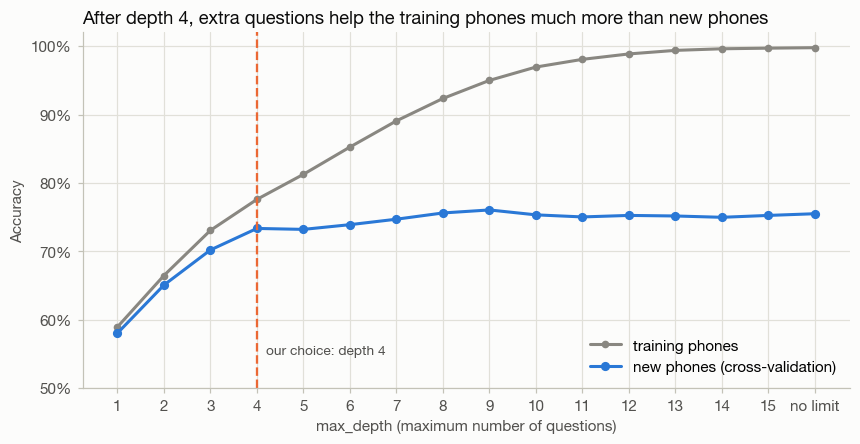

In [6]:
x = np.arange(len(depth_results))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, depth_results["training accuracy"], color=MUTED, marker="o", markersize=4, label="training phones")
ax.plot(x, depth_results["CV accuracy"], color=BLUE, marker="o", markersize=5, label="new phones (cross-validation)")
chosen = list(depth_results.index).index(str(chosen_depth))
ax.axvline(chosen, color=ORANGE, linewidth=1.5, linestyle="--")
ax.annotate(f"our choice: depth {chosen_depth}", (chosen, 0.55), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_xticks(x, depth_results.index)
ax.set_ylim(0.5, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("max_depth (maximum number of questions)")
ax.set_ylabel("Accuracy")
ax.set_title(f"After depth {chosen_depth}, extra questions help the training phones much more than new phones")
ax.legend(loc="lower right")
save(fig, "t4_01_tree_depth")
plt.show()

- The **training accuracy** (grey) keeps rising with depth, up to 99.8% for an unlimited tree: a deep tree learns the training phones by heart.
- The **cross-validation accuracy** (blue, new phones) rises quickly at first: each of the first levels adds 3 to 7 percentage points, up to **73.4% at depth 4**. After that, every extra level adds less than 1 point.
- The most accurate depth is 9 (76.1%). But it is only 2.7 points better than depth 4, and its tree has 101 leaves instead of 16.
- So **depth 4 is our choice for 4a**: the point where a bigger tree stops paying off. With at most 4 questions per phone, we can draw the whole tree and explain every decision.

### 4b · Different numbers of phones in a leaf
Now we keep the depth from 4a and change only `min_samples_leaf`, the minimum number of training phones in each leaf. With 1, a leaf may describe a single phone; with 50, every answer must be backed by at least 50 phones. Bigger leaves also make the tree smaller.

In [7]:
leaf_sizes = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 75, 100]
leaf_results = pd.DataFrame([cv_scores(max_depth=chosen_depth, min_samples_leaf=n) for n in leaf_sizes], index=leaf_sizes)
leaf_results.index.name = "min_samples_leaf"

# The best CV accuracy; if two leaf sizes are equally good, we take the bigger leaves (a smaller tree)
top = leaf_results["CV accuracy"].round(4)
chosen_leaf = int(top.index[top == top.max()][-1])
ours = leaf_results.loc[chosen_leaf]
print(f"Depth {chosen_depth}: best CV accuracy with {chosen_leaf} phones per leaf ({ours['CV accuracy']:.1%}, {ours['leaves']:.0f} leaves)")
leaf_results.style.format({"training accuracy": "{:.1%}", "CV accuracy": "{:.1%}", "leaves": "{:.0f}"})

Depth 4: best CV accuracy with 3 phones per leaf (73.4%, 15 leaves)


,training accuracy,CV accuracy,leaves
min_samples_leaf,,,
1,77.6%,73.4%,16
2,77.4%,73.3%,15
3,77.4%,73.4%,15
4,77.1%,73.3%,16
5,76.8%,73.2%,16
6,76.6%,73.1%,15
8,76.1%,72.5%,15
10,75.9%,72.3%,14
12,75.5%,72.0%,14


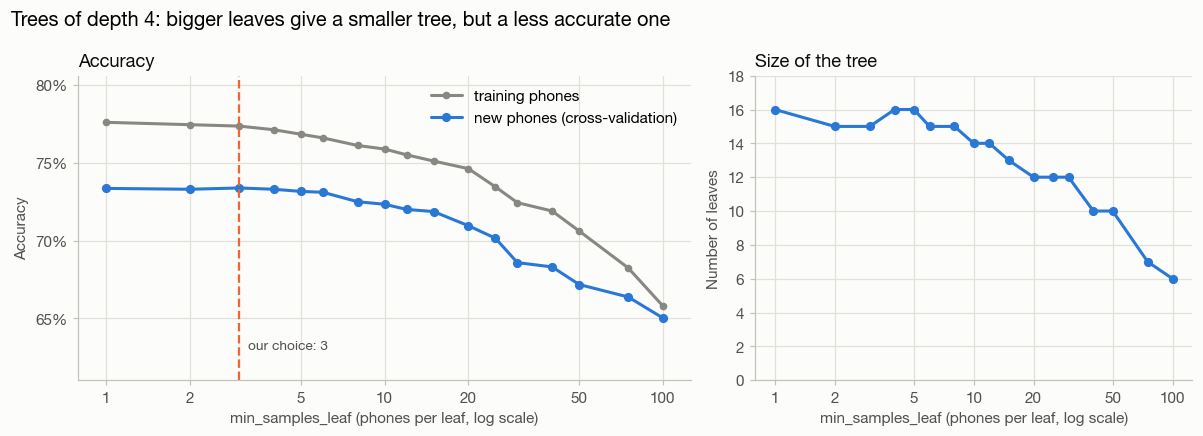

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
ax.plot(leaf_sizes, leaf_results["training accuracy"], color=MUTED, marker="o", markersize=4, label="training phones")
ax.plot(leaf_sizes, leaf_results["CV accuracy"], color=BLUE, marker="o", markersize=5, label="new phones (cross-validation)")
ax.axvline(chosen_leaf, color=ORANGE, linewidth=1.5, linestyle="--")
low = leaf_results[["training accuracy", "CV accuracy"]].min().min()
ax.annotate(f"our choice: {chosen_leaf}", (chosen_leaf, low - 0.02), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_ylim(low - 0.04, leaf_results["training accuracy"].max() + 0.03)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(leaf_sizes, leaf_results["leaves"], color=BLUE, marker="o", markersize=5)
ax.set_ylim(0, leaf_results["leaves"].max() + 2)
ax.set_ylabel("Number of leaves")
ax.set_title("Size of the tree")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100], ["1", "2", "5", "10", "20", "50", "100"])
    ax.minorticks_off()
    ax.set_xlabel("min_samples_leaf (phones per leaf, log scale)")
fig.suptitle(f"Trees of depth {chosen_depth}: bigger leaves give a smaller tree, but a less accurate one",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t4_02_leaf_size")
plt.show()

- For trees of depth 4, the cross-validation accuracy is almost the same for 1 to 6 phones per leaf (73.1–73.4%). With bigger leaves it falls: 72.0% with 12, 71.0% with 20 and 65.0% with 100 phones per leaf.
- Bigger leaves make the tree smaller: from 16 leaves (1 phone per leaf) down to 6 leaves (100 phones per leaf).
- The best value is with **3 phones per leaf (73.4%, 15 leaves)**, so this is our choice for 4b.
- A tree of depth 4 hardly overfits: it is right for 77.4% of the training phones and 73.4% of new phones.

### 4c · All combinations: what we give up for a small tree
To check our choice, we test every combination of depth and leaf size: 12 depths × 10 leaf sizes = 120 trees, each with 25 cross-validation runs.

In [9]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    {"max_depth": list(range(2, 13)) + [None], "min_samples_leaf": [1, 2, 3, 5, 8, 10, 12, 15, 20, 30]},
                    cv=cv, scoring="accuracy").fit(X_train, y_train)
grid_results = pd.DataFrame(grid.cv_results_)
grid_results["max_depth"] = grid_results["param_max_depth"].map(lambda d: "no limit" if pd.isna(d) else str(int(d)))
grid_results["min_samples_leaf"] = grid_results["param_min_samples_leaf"].astype(int)
grid_results["leaves"] = [DecisionTreeClassifier(random_state=42, **p).fit(X_train, y_train).get_n_leaves()
                          for p in grid_results["params"]]

final_settings = {"max_depth": chosen_depth, "min_samples_leaf": chosen_leaf}          # our tree from 4a and 4b
best = grid_results.loc[grid_results["mean_test_score"].idxmax()]
ours = grid_results[(grid_results["max_depth"] == str(chosen_depth)) & (grid_results["min_samples_leaf"] == chosen_leaf)].iloc[0]
print(f"Most accurate combination: max_depth = {best['max_depth']}, min_samples_leaf = {best['min_samples_leaf']} "
      f"({best['mean_test_score']:.1%}, {best['leaves']} leaves)")
print(f"Our tree:                  max_depth = {ours['max_depth']}, min_samples_leaf = {ours['min_samples_leaf']} "
      f"({ours['mean_test_score']:.1%}, {ours['leaves']} leaves)")

Most accurate combination: max_depth = 9, min_samples_leaf = 1 (76.1%, 101 leaves)
Our tree:                  max_depth = 4, min_samples_leaf = 3 (73.4%, 15 leaves)


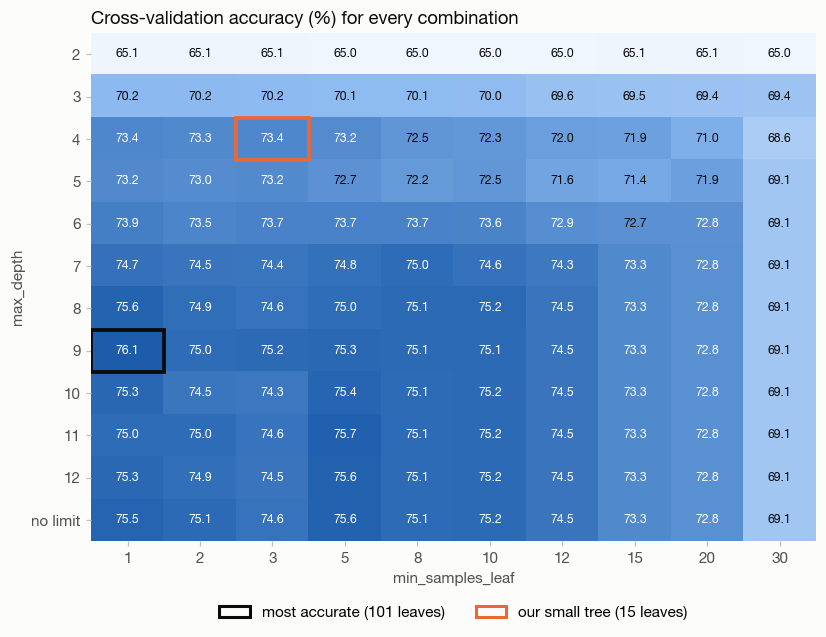

In [10]:
table = grid_results.pivot(index="max_depth", columns="min_samples_leaf", values="mean_test_score")
table = table.reindex([str(d) for d in range(2, 13)] + ["no limit"])
blues = LinearSegmentedColormap.from_list("blues", ["#f0f6fe", "#86b6ef", "#1c5cab"])

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.imshow(table.values, cmap=blues, aspect="auto")
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        v = table.values[i, j]
        ax.text(j, i, f"{v:.1%}".replace("%", ""), ha="center", va="center", fontsize=8,
                color="white" if v > table.values.min() + 0.7 * (table.values.max() - table.values.min()) else INK)
for row, col, color in [(best["max_depth"], best["min_samples_leaf"], INK), (ours["max_depth"], ours["min_samples_leaf"], ORANGE)]:
    i, j = list(table.index).index(row), list(table.columns).index(col)
    ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=2.5))
ax.set_xticks(range(table.shape[1]), table.columns)
ax.set_yticks(range(table.shape[0]), table.index)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(handles=[Patch(facecolor="none", edgecolor=INK, linewidth=2, label=f"most accurate ({best['leaves']} leaves)"),
                   Patch(facecolor="none", edgecolor=ORANGE, linewidth=2, label=f"our small tree ({ours['leaves']} leaves)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_title("Cross-validation accuracy (%) for every combination")
save(fig, "t4_03_grid_search")
plt.show()

The most accurate combination is depth 9 with 1 phone per leaf (76.1%), but its tree has 101 leaves. **Our tree (max_depth = 4, min_samples_leaf = 3) reaches 73.4% with only 15 leaves**: 2.7 points less, for a tree that is almost 7 times smaller and fits on one slide (see 5.3). **This is our final tree.**

## Part 5 · Evaluating our final tree
Now we train the final tree on the whole training set and use the **test set** for the first and only time. We compare it with two other models:
- a **baseline** that always answers the most common segment (Budget): every model must beat it,
- the **unlimited tree**, which grows until every leaf is pure: it shows what happens without our settings.

### 5.1 Classification quality on the test set
**Our metrics** (for 4 classes we compute precision, recall and F1 for each segment, and then take the simple average over the 4 segments, the *macro average*, so that the small Flagship segment counts as much as the big Budget segment):
- **Accuracy:** the share of phones we put in the right segment.
- **Precision:** of the phones we call "Flagship", the share that really are flagships (the same for each segment).
- **Recall:** of the real flagships, the share that we find.
- **F1-score:** the harmonic mean of precision and recall.
- **ROC-AUC (one-vs-rest):** for each segment, how well the tree ranks its phones above all other phones (0.5 = guessing, 1 = perfect), averaged over the 4 segments.

In [11]:
tree = DecisionTreeClassifier(random_state=42, **final_settings).fit(X_train, y_train)
full_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
most_common = y_train.value_counts().idxmax()

def metrics(name, model, X_part, y_part):
    if model is None:          # the baseline: always the most common segment
        predicted, proba = np.full(len(y_part), most_common), np.tile(np.eye(4)[most_common], (len(y_part), 1))
    else:
        predicted, proba = model.predict(X_part), model.predict_proba(X_part)
    return {"model": name, "accuracy": accuracy_score(y_part, predicted),
            "precision (macro)": precision_score(y_part, predicted, average="macro", zero_division=0),
            "recall (macro)": recall_score(y_part, predicted, average="macro"),
            "F1 (macro)": f1_score(y_part, predicted, average="macro"),
            "ROC-AUC (one-vs-rest)": roc_auc_score(y_part, proba, multi_class="ovr", labels=[0, 1, 2, 3])}

results = pd.DataFrame([metrics("baseline: always Budget", None, X_test, y_test),
                        metrics("unlimited tree", full_tree, X_test, y_test),
                        metrics("our tree", tree, X_test, y_test),
                        metrics("our tree, on the training set", tree, X_train, y_train)]).set_index("model")
results.style.format("{:.3f}")

,accuracy,precision (macro),recall (macro),F1 (macro),ROC-AUC (one-vs-rest)
model,,,,,
baseline: always Budget,0.357,0.089,0.250,0.132,0.500
unlimited tree,0.780,0.811,0.800,0.803,0.859
our tree,0.797,0.820,0.816,0.814,0.916
"our tree, on the training set",0.775,0.758,0.770,0.763,0.929


In [12]:
predicted = tree.predict(X_test)
report = pd.DataFrame(classification_report(y_test, predicted, target_names=SEGMENTS, output_dict=True)).T
report.loc[SEGMENTS + ["macro avg"], ["precision", "recall", "f1-score", "support"]].style.format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"})

,precision,recall,f1-score,support
Budget,0.889,0.738,0.807,65
Mid-range,0.701,0.831,0.761,65
Premium,0.821,0.742,0.780,31
Flagship,0.870,0.952,0.909,21
macro avg,0.820,0.816,0.814,182


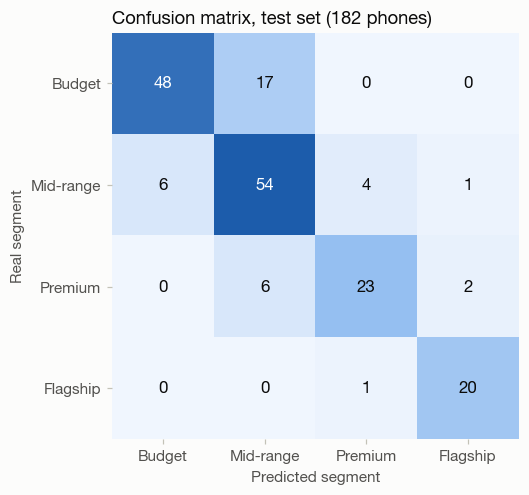

More than one segment off: Google Pixel 6A (real: Mid-range, predicted: Flagship, price 333 EUR)


,predicted: Budget,predicted: Mid-range,predicted: Premium,predicted: Flagship
real: Budget,48,17,0,0
real: Mid-range,6,54,4,1
real: Premium,0,6,23,2
real: Flagship,0,0,1,20


In [13]:
cm = confusion_matrix(y_test, predicted, labels=[0, 1, 2, 3])
blues = LinearSegmentedColormap.from_list("blues", ["#f0f6fe", "#86b6ef", "#1c5cab"])
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.imshow(cm, cmap=blues)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11, fontweight="semibold" if i == j else "normal",
                color="white" if cm[i, j] > cm.max() * 0.6 else INK)
ax.set_xticks(range(4), SEGMENTS)
ax.set_yticks(range(4), SEGMENTS)
ax.set_xlabel("Predicted segment")
ax.set_ylabel("Real segment")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"Confusion matrix, test set ({len(y_test)} phones)")
save(fig, "t4_05_confusion_matrix")
plt.show()
for i in X_test.index[np.abs(predicted - y_test.values) > 1]:          # mistakes of more than one segment
    print(f"More than one segment off: {df.loc[i, 'model']} (real: {SEGMENTS[y[i]]}, predicted: "
          f"{SEGMENTS[predicted[list(X_test.index).index(i)]]}, price {df.loc[i, 'price_eur']:.0f} EUR)")
pd.DataFrame(cm, index=[f"real: {s}" for s in SEGMENTS], columns=[f"predicted: {s}" for s in SEGMENTS])

- **Our tree puts 79.7% of the test phones in the right segment**, more than twice as many as the baseline (35.7%). Its macro F1 is 0.81 and its ROC-AUC 0.92.
- **It is as good as the unlimited tree with a tenth of the leaves** (15 vs 149): accuracy 79.7% vs 78.0%, macro F1 0.81 vs 0.80. And its probabilities are better (ROC-AUC 0.92 vs 0.86): the leaves of the unlimited tree are pure, so it can only say 0% or 100%.
- On the test set our tree is even a bit better than on the training set (79.7% vs 77.5%): this test set happens to be a little easier. In 5.4 we check what is typical.
- **Flagship is the easiest segment** (F1 0.91): flagships stand out with fast processors, lots of RAM, big or foldable screens, or the iPhone's 12 MP front camera. **Mid-range is the hardest** (F1 0.76): it sits between Budget and Premium, and the tree calls 17 of the 65 Budget phones Mid-range.
- **All mistakes but one are between neighbouring segments.** The one exception is the Google Pixel 6a: a Mid-range phone (€333) with the same Tensor chip as Google's flagships, so the tree called it a Flagship.

### 5.2 Model characteristics
How big is our tree, how much did it overfit, and which specs does it use?

In [14]:
used = (tree.feature_importances_ > 0).sum()
characteristics = pd.DataFrame({
    "our tree": [tree.get_depth(), tree.get_n_leaves(), tree.tree_.node_count, used,
                 tree.score(X_train, y_train), tree.score(X_test, y_test)],
    "unlimited tree": [full_tree.get_depth(), full_tree.get_n_leaves(), full_tree.tree_.node_count,
                       (full_tree.feature_importances_ > 0).sum(), full_tree.score(X_train, y_train), full_tree.score(X_test, y_test)],
}, index=["depth", "leaves", "nodes (questions + leaves)", "features used (of 27)", "training accuracy", "test accuracy"])
characteristics.style.format("{:.0f}").format("{:.1%}", subset=pd.IndexSlice[["training accuracy", "test accuracy"], :])

,our tree,unlimited tree
depth,4,14
leaves,15,149
nodes (questions + leaves),29,297
features used (of 27),9,22
training accuracy,77.5%,99.7%
test accuracy,79.7%,78.0%


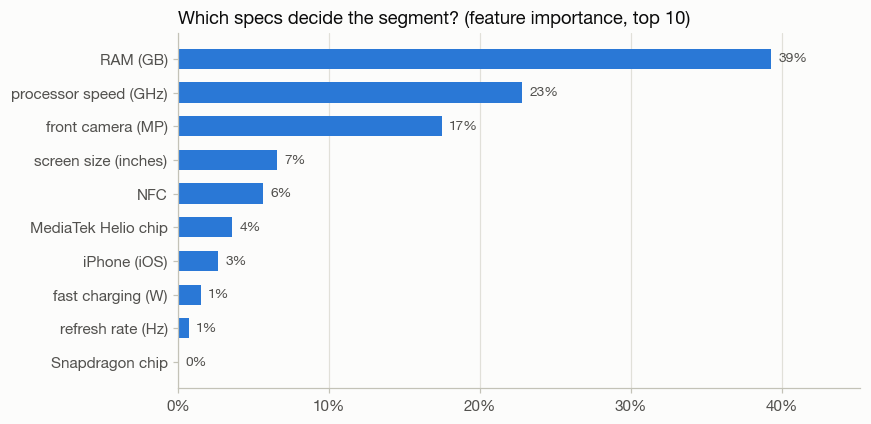

The top 2 features together: 62.1% | features not used at all: 18


,importance
RAM (GB),39.3%
processor speed (GHz),22.8%
front camera (MP),17.4%
screen size (inches),6.5%
NFC,5.6%
MediaTek Helio chip,3.5%
iPhone (iOS),2.6%
fast charging (W),1.5%
refresh rate (Hz),0.7%
Snapdragon chip,0.0%


In [15]:
importance = pd.Series(tree.feature_importances_, index=[NAMES[f] for f in features]).sort_values(ascending=False)
top = importance.head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.index, top.values, height=0.6, color=BLUE)
for yy, v in enumerate(top.values):
    ax.text(v + 0.005, yy, f"{v:.0%}", va="center", fontsize=9, color=INK2)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, top.max() * 1.15)
ax.grid(axis="y", visible=False)
ax.set_title("Which specs decide the segment? (feature importance, top 10)")
save(fig, "t4_06_feature_importance")
plt.show()
print(f"The top 2 features together: {importance.iloc[:2].sum():.1%} | features not used at all: {(importance == 0).sum()}")
importance.head(10).to_frame("importance").style.format("{:.1%}")

- **Our tree** has a depth of 4, 15 leaves and 29 nodes (14 questions and 15 leaves). It uses only 9 of the 27 features.
- **No overfitting:** our tree is right for 77.5% of the training phones and 79.7% of the test phones. The unlimited tree has a gap of 21.7 points (99.7% vs 78.0%): it learned the training phones by heart.
- **RAM (39.3%) and processor speed (22.8%)** make up 62.1% of the tree's decisions: the same two specs that drive the price in our linear regression in Task 3.
- The **front camera** is third (17.4%). The tree uses it to separate phones with similar RAM and processors, and a 12 MP front camera is typical of iPhones (see rule #3 in Part 6).
- 18 of the 27 features are not used at all.

### 5.3 Our tree
Our tree is small enough to show completely. Each box shows the question, the number of training phones that reach it, and the segment the tree predicts there; the colour shows that segment (light = Budget, dark = Flagship). If the answer to a question is **yes, the phone goes left**; if it is no, it goes right. For yes/no features, "≤ 0.5" means "No".

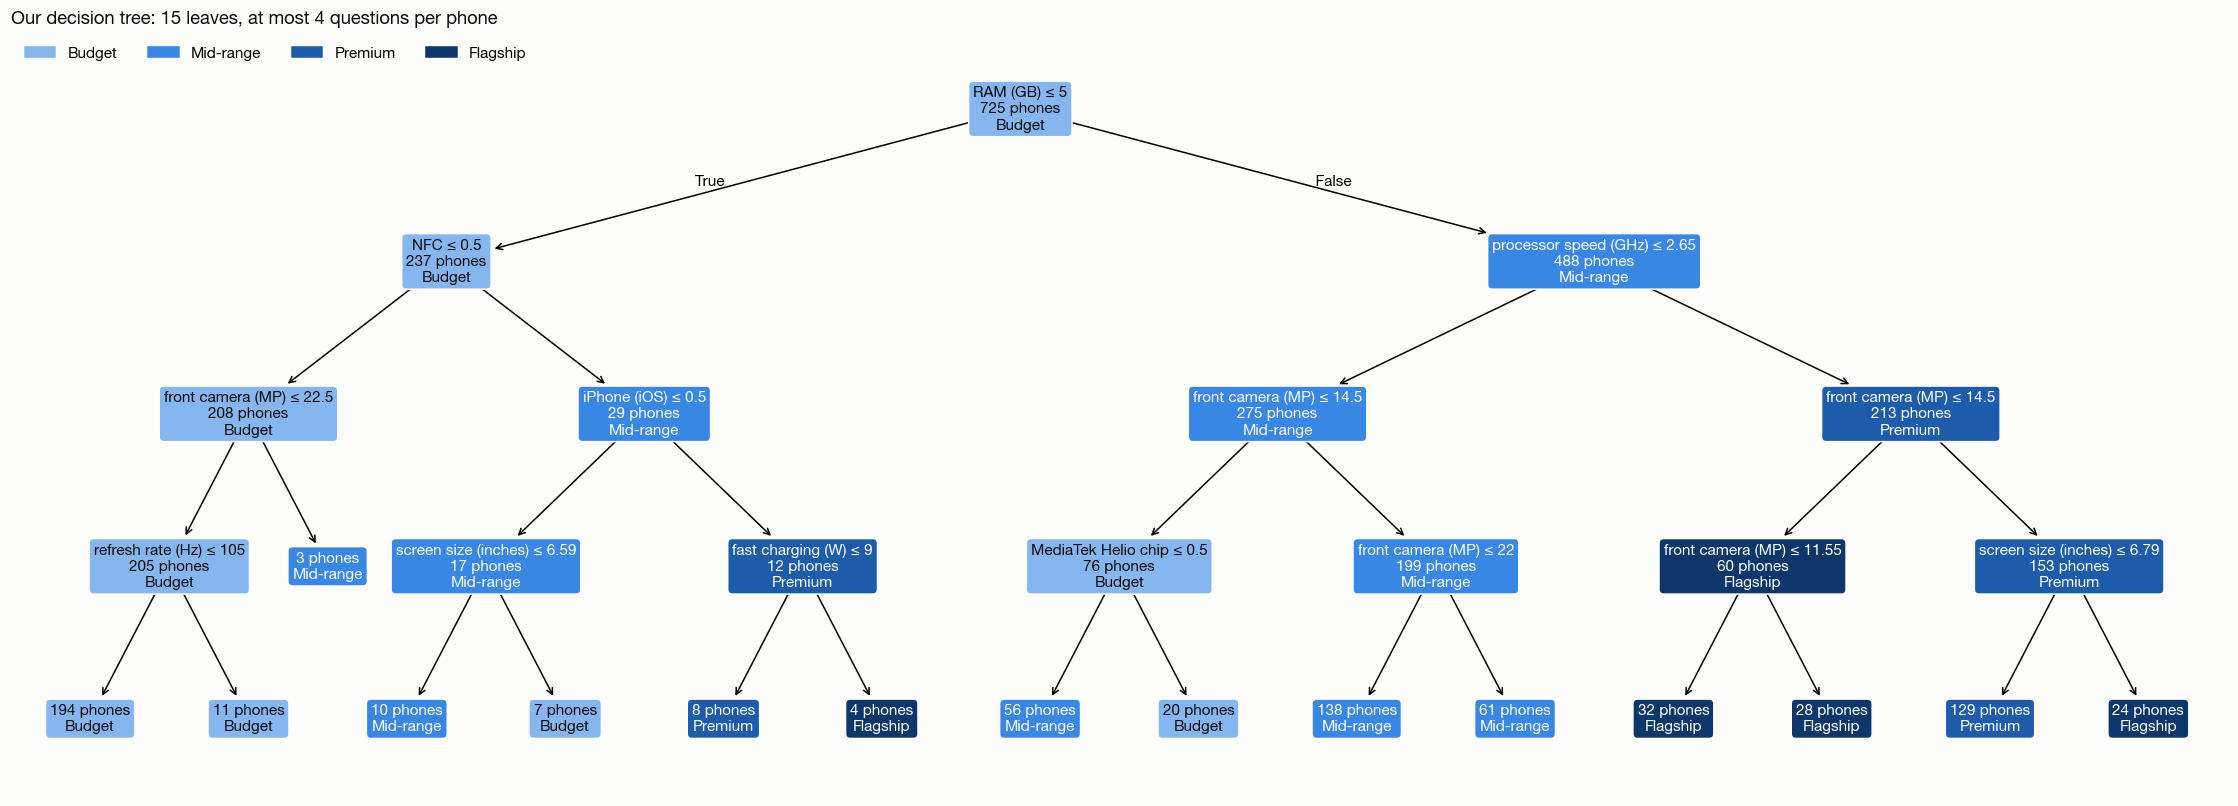

Phones in the big-screen leaf: 24, of them foldables: 12


In [16]:
fig, ax = plt.subplots(figsize=(26, 9))
boxes = plot_tree(tree, feature_names=[NAMES[f] for f in features], class_names=SEGMENTS,
                  filled=True, impurity=False, rounded=True, fontsize=10, ax=ax)
for box in boxes:          # we keep the question, the number of phones and the segment, in our colours
    lines = box.get_text().split("\n")
    if not any(l.startswith("class = ") for l in lines):          # the "True" / "False" labels of the first arrows
        continue
    segment = SEGMENTS.index([l for l in lines if l.startswith("class = ")][0].split("class = ")[1])
    question = [re.sub(r"(\d+)\.0\b", r"\1", l.replace("<=", "≤")) for l in lines if "<=" in l]          # 5.0 -> 5
    phones = [l.replace("samples = ", "") + " phones" for l in lines if l.startswith("samples = ")]
    box.set_text("\n".join(question + phones + [SEGMENTS[segment]]))
    box.get_bbox_patch().set_facecolor(SEGMENT_COLORS[segment])
    box.get_bbox_patch().set_edgecolor(SURFACE)
    box.set_color(INK if segment == 0 else "white")
ax.legend(handles=[Patch(color=c, label=s) for s, c in zip(SEGMENTS, SEGMENT_COLORS)], loc="upper left", ncol=4)
ax.set_title(f"Our decision tree: {tree.get_n_leaves()} leaves, at most {tree.get_depth()} questions per phone")
save(fig, "t4_04_decision_tree")
plt.show()

# Who is in the leaf "fast processor, front camera above 14.5 MP, big screen"?
leaf_ids = tree.apply(X_train)
fast_big = leaf_ids == tree.apply(X_train[(X_train["ram_capacity"] > 5) & (X_train["processor_speed"] > 2.65) &
                                          (X_train["primary_camera_front"] > 14.5) & (X_train["screen_size"] > 6.79)].iloc[:1])[0]
print(f"Phones in the big-screen leaf: {fast_big.sum()}, of them foldables: {X_train.loc[fast_big, 'is_foldable'].sum()}")

- **The first question is about RAM.** Phones with at most 4 GB of RAM (RAM ≤ 5 GB) go left (237 training phones), the others go right (488 phones).
- **On the left**, the tree asks about NFC. The biggest leaf of the tree is here: 194 phones with at most 4 GB of RAM, no NFC, a front camera up to 22 MP and a refresh rate up to 105 Hz are **Budget** phones.
- **On the right**, the tree asks about the processor: up to 2.65 GHz, phones are mostly **Mid-range** (275 phones); faster phones are **Premium or Flagship** (213 phones).
- Among the fast phones, a front camera up to 14 MP points to a **Flagship** (60 phones, including the iPhones with their 12 MP front cameras), and so does a big screen above 6.79 inches (24 phones, half of them foldables). The rest are **Premium** phones (129).
- So the tree reads like a buyer's checklist: **first RAM, then NFC or the processor, then the front camera or the screen**.

The full tree as text (each line is one question; `class` is the predicted segment, 0 = Budget, 1 = Mid-range, 2 = Premium, 3 = Flagship):

In [17]:
print(export_text(tree, feature_names=[NAMES[f] for f in features], decimals=2))

|--- RAM (GB) <= 5.00
|   |--- NFC <= 0.50
|   |   |--- front camera (MP) <= 22.50
|   |   |   |--- refresh rate (Hz) <= 105.00
|   |   |   |   |--- class: 0
|   |   |   |--- refresh rate (Hz) >  105.00
|   |   |   |   |--- class: 0
|   |   |--- front camera (MP) >  22.50
|   |   |   |--- class: 1
|   |--- NFC >  0.50
|   |   |--- iPhone (iOS) <= 0.50
|   |   |   |--- screen size (inches) <= 6.59
|   |   |   |   |--- class: 1
|   |   |   |--- screen size (inches) >  6.59
|   |   |   |   |--- class: 0
|   |   |--- iPhone (iOS) >  0.50
|   |   |   |--- fast charging (W) <= 9.00
|   |   |   |   |--- class: 2
|   |   |   |--- fast charging (W) >  9.00
|   |   |   |   |--- class: 3
|--- RAM (GB) >  5.00
|   |--- processor speed (GHz) <= 2.65
|   |   |--- front camera (MP) <= 14.50
|   |   |   |--- MediaTek Helio chip <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- MediaTek Helio chip >  0.50
|   |   |   |   |--- class: 0
|   |   |--- front camera (MP) >  14.50
|   |   |   |--- front 

### 5.4 How stable is our result?
Our test set is only one random fifth of the data. To see how much the result depends on this luck, we repeat the split 20 times with different random seeds, train a tree with our final settings each time, and test it.

In [18]:
accuracies = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    accuracies.append(DecisionTreeClassifier(random_state=42, **final_settings).fit(X_tr, y_tr).score(X_te, y_te))
accuracies = pd.Series(accuracies)
print(f"Test accuracy over 20 random splits: mean {accuracies.mean():.1%}, from {accuracies.min():.1%} to {accuracies.max():.1%} "
      f"(standard deviation {accuracies.std():.1%})")

Test accuracy over 20 random splits: mean 74.7%, from 68.7% to 82.4% (standard deviation 3.5%)


Depending on which phones land in the test set, the accuracy of the same tree settings goes from 68.7% to 82.4%, with a mean of **74.7%**. So our 79.7% is a bit above average. The honest summary is: **our tree puts about 3 out of 4 phones (75%) in the right segment**, give or take 4 points. This also agrees with the cross-validation estimate from Part 4 (73.4%).

## Part 6 · Optional: decision rules from our tree
Every path from the top of the tree to a leaf is an **IF … THEN** rule: IF all the answers on the path are true, THEN the phone is in the leaf's segment. So our tree gives one rule per leaf. We make the rules simpler and turn them into a rule-based classifier in four steps (the idea of the classic C4.5rules method):

1. **Read the rules:** one rule per leaf. If a path asks about the same feature twice, we keep only the stricter condition.
2. **Simplify each rule:** we try to drop each condition. If the rule stays at least as accurate on the training phones, the condition wasn't needed, and we drop it. To measure accuracy we use the *Laplace estimate*, (correct + 1) / (covered + 4), which doesn't trust rules that cover very few phones.
3. **Order the rules and remove the weak ones:** we sort the rules from the most to the least accurate. A rule must cover at least 5 training phones that no earlier rule covers; otherwise we drop it.
4. **Classify:** for a phone we go through the rules in order, and the **first rule that matches** decides. If no rule matches, a **default rule** gives the most common segment of the training phones that no rule covers.

In [19]:
def tree_to_rules(model):
    # Step 1: one rule per leaf, made of the conditions on the path from the top to the leaf
    t, rules = model.tree_, []
    def walk(node, conditions):
        if t.children_left[node] == -1:          # a leaf
            rules.append(conditions)
            return
        feature, threshold = features[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], conditions + [(feature, "<=", threshold)])
        walk(t.children_right[node], conditions + [(feature, ">", threshold)])
    walk(0, [])
    return [keep_strictest(conditions) for conditions in rules]

def keep_strictest(conditions):
    # If the path asks about the same feature twice in the same direction, the stricter condition is enough
    strictest = {}
    for feature, op, threshold in conditions:
        key = (feature, op)
        if key not in strictest or (threshold < strictest[key] if op == "<=" else threshold > strictest[key]):
            strictest[key] = threshold
    return [(feature, op, threshold) for (feature, op), threshold in strictest.items()]

def matches(conditions, data):
    # Which phones meet all the conditions of a rule?
    mask = np.ones(len(data), dtype=bool)
    for feature, op, threshold in conditions:
        mask &= (data[feature].values <= threshold) if op == "<=" else (data[feature].values > threshold)
    return mask

def quality(conditions, label, data, target):
    # How many training phones a rule covers, how many it gets right, and its Laplace accuracy
    covered = matches(conditions, data)
    correct = int((target.values[covered] == label).sum())
    return int(covered.sum()), correct, (correct + 1) / (covered.sum() + 4)

def simplify(conditions, label):
    # Step 2: drop conditions as long as the rule doesn't get less accurate
    covered, correct, laplace = quality(conditions, label, X_train, y_train)
    dropped = True
    while dropped and conditions:
        dropped = False
        for condition in conditions:
            shorter = [c for c in conditions if c != condition]
            covered2, correct2, laplace2 = quality(shorter, label, X_train, y_train)
            if laplace2 >= laplace:
                conditions, covered, correct, laplace, dropped = shorter, covered2, correct2, laplace2, True
                break
    return conditions, covered, correct, laplace

In [20]:
candidates = []
for conditions in tree_to_rules(tree):
    label = int(y_train[matches(conditions, X_train)].value_counts().idxmax())          # the leaf's segment
    conditions, covered, correct, laplace = simplify(conditions, label)
    candidates.append({"conditions": conditions, "segment": label, "covered": covered, "correct": correct, "laplace": laplace})

# Step 3: order by accuracy; a rule must cover at least 5 training phones that no earlier rule covers
rules, already = [], np.zeros(len(X_train), dtype=bool)
for rule in sorted(candidates, key=lambda r: (-r["laplace"], -r["covered"])):
    new = matches(rule["conditions"], X_train) & ~already
    if new.sum() >= 5:
        rules.append(rule)
        already |= new
default_segment = int(y_train[~already].value_counts().idxmax()) if (~already).any() else int(most_common)

def predict_with_rules(data):
    # Step 4: the first matching rule decides; otherwise the default rule
    predicted = np.full(len(data), default_segment)
    which_rule = np.full(len(data), -1)
    for number, rule in enumerate(rules):
        hit = matches(rule["conditions"], data) & (which_rule == -1)
        predicted[hit], which_rule[hit] = rule["segment"], number
    return predicted, which_rule

print(f"{tree.get_n_leaves()} rules from the leaves -> {len(rules)} rules after simplifying, plus a default rule "
      f"({SEGMENTS[default_segment]}) | training phones covered by a rule: {already.mean():.1%}")

15 rules from the leaves -> 14 rules after simplifying, plus a default rule (Flagship) | training phones covered by a rule: 99.4%


### 6.1 Our rules

In [21]:
BINARY = {"has_5g": ("5G", "no 5G"), "has_nfc": ("NFC", "no NFC"), "has_ir_blaster": ("IR blaster", "no IR blaster"),
          "extended_memory_available": ("memory-card slot", "no memory-card slot"),
          "os_ios": ("iPhone", "not an iPhone"), "is_foldable": ("foldable", "not foldable")}
UNITS = {"processor_speed": ("processor speed", "GHz"), "ram_capacity": ("RAM", "GB"), "internal_memory": ("storage", "GB"),
         "battery_capacity": ("battery", "mAh"), "fast_charging": ("fast charging", "W"), "screen_size": ("screen", "inches"),
         "refresh_rate": ("refresh rate", "Hz"), "primary_camera_rear": ("main camera", "MP"),
         "primary_camera_front": ("front camera", "MP"), "num_rear_cameras": ("rear cameras", ""), "ppi": ("pixel density", "ppi")}

def number(v):
    return f"{v:,.0f}" if abs(v - round(v)) < 1e-9 else f"{v:,.2f}".rstrip("0").rstrip(".")

def rule_text(conditions):
    # Turns the conditions into readable English, e.g. "RAM ≤ 5 GB and no NFC"
    parts, bounds = [], {}
    for feature, op, threshold in conditions:
        if feature in BINARY or feature.startswith("chip_"):
            yes, no = BINARY.get(feature, (NAMES[feature], f"not a {NAMES[feature]}"))
            parts.append(yes if op == ">" else no)
        else:
            bounds.setdefault(feature, {})[op] = threshold
    for feature, b in bounds.items():
        name, unit = UNITS[feature]
        unit = f" {unit}" if unit else ""
        if "<=" in b and ">" in b:
            parts.append(f"{number(b['>'])} < {name} ≤ {number(b['<='])}{unit}")
        elif "<=" in b:
            parts.append(f"{name} ≤ {number(b['<='])}{unit}")
        else:
            parts.append(f"{name} > {number(b['>'])}{unit}")
    return " and ".join(sorted(parts, key=lambda p: (p.startswith(("no ", "not ")), p))) or "(always)"

rule_table = pd.DataFrame([{"#": i + 1, "IF": rule_text(r["conditions"]), "THEN": SEGMENTS[r["segment"]],
                            "training phones covered": r["covered"], "accuracy on them": r["correct"] / r["covered"]}
                           for i, r in enumerate(rules)])
rule_table.loc[len(rule_table)] = [len(rules) + 1, "no rule above matches", SEGMENTS[default_segment],
                                   int((~already).sum()), np.nan]
rule_table.style.format({"accuracy on them": "{:.0%}"}, na_rep="").format(escape="html", subset=["IF"]).hide(axis="index")

#,IF,THEN,training phones covered,accuracy on them
1,MediaTek Helio chip and front camera ≤ 14.5 MP,Budget,102,95%
2,RAM ≤ 5 GB and front camera ≤ 22.5 MP and refresh rate ≤ 105 Hz and no NFC,Budget,194,94%
3,11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz,Flagship,28,100%
4,RAM ≤ 5 GB and no NFC,Budget,208,91%
5,RAM ≤ 5 GB and screen > 6.59 inches,Budget,55,91%
6,14.5 < front camera ≤ 22 MP and RAM > 5 GB and processor speed ≤ 2.65 GHz,Mid-range,138,81%
7,RAM > 5 GB and processor speed ≤ 2.65 GHz and not a MediaTek Helio chip,Mid-range,219,73%
8,processor speed > 2.65 GHz and screen > 6.79 inches,Flagship,31,77%
9,NFC and RAM ≤ 5 GB and screen ≤ 6.59 inches and not an iPhone,Mid-range,10,90%
10,RAM ≤ 5 GB and fast charging ≤ 9 W and iPhone,Premium,8,88%


In [22]:
# Which phones are behind the Flagship rules? We count the iPhones among the training phones each rule covers
is_iphone = df.loc[X_train.index, "brand_name"].eq("apple").values
display(pd.DataFrame([{"rule": f"#{i + 1}", "IF": rule_text(r["conditions"]), "training phones covered": r["covered"],
                       "of them iPhones": int(is_iphone[matches(r["conditions"], X_train)].sum())}
                      for i, r in enumerate(rules) if r["segment"] == 3]).style.format(escape="html", subset=["IF"]).hide(axis="index"))
iphones = df[df["brand_name"] == "apple"]
print(f"iPhones with a 12 MP front camera: {(iphones['primary_camera_front'] == 12).sum()} of {len(iphones)}")

rule,IF,training phones covered,of them iPhones
#3,11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz,28,18
#8,processor speed > 2.65 GHz and screen > 6.79 inches,31,0
#14,RAM > 5 GB and front camera ≤ 11.55 MP and processor speed > 2.65 GHz,32,0


iPhones with a 12 MP front camera: 37 of 40


Our tree's 15 leaves became **14 rules plus a default rule**. Some rules are very short and easy to read:
- **#1: a MediaTek Helio chip and a front camera up to 14 MP → Budget** (95% of 102 training phones).
- **#4: 4 GB of RAM or less (RAM ≤ 5 GB) and no NFC → Budget** (91% of 208 phones).
- **#8: a fast processor (> 2.65 GHz) and a big screen (> 6.79 inches) → Flagship** (77% of 31 phones).
- **#3: a fast processor (> 2.65 GHz), more than 4 GB of RAM and a 12–14 MP front camera → Flagship** (28 of 28). 18 of these 28 phones are iPhones, because 37 of our 40 iPhones have a 12 MP front camera: **the tree found the iPhones through their selfie camera**, not through the "iPhone" feature.

The least accurate rules (#13 and #14, 58% and 56%) describe the border between Premium and Flagship: this is the hardest border to draw from the specs alone.

### 6.2 Classification with the rules, and rules vs tree
We classify the test phones with our rules and compare them with the tree they came from.

In [23]:
rule_predictions, fired = predict_with_rules(X_test)
tree_predictions = tree.predict(X_test)
avg_conditions_tree = np.mean([len(c) for c in tree_to_rules(tree)])
avg_conditions_rules = np.mean([len(r["conditions"]) for r in rules])

comparison = pd.DataFrame({
    "decision tree": [accuracy_score(y_test, tree_predictions), f1_score(y_test, tree_predictions, average="macro"),
                      tree.get_n_leaves(), avg_conditions_tree],
    "decision rules": [accuracy_score(y_test, rule_predictions), f1_score(y_test, rule_predictions, average="macro"),
                       len(rules) + 1, avg_conditions_rules],
}, index=["test accuracy", "test F1 (macro)", "number of leaves / rules (with the default rule)", "conditions per leaf / rule"])
display(comparison.style.format("{:.3f}").format("{:.0f}", subset=pd.IndexSlice[["number of leaves / rules (with the default rule)"], :])
        .format("{:.1f}", subset=pd.IndexSlice[["conditions per leaf / rule"], :]))
print(f"The two classifiers give the same answer for {np.mean(tree_predictions == rule_predictions):.1%} of the test phones "
      f"({(tree_predictions != rule_predictions).sum()} of {len(y_test)} differ) | test phones decided by the default rule: "
      f"{(fired == -1).sum()}")

,decision tree,decision rules
test accuracy,0.797,0.786
test F1 (macro),0.814,0.801
number of leaves / rules (with the default rule),15,15
conditions per leaf / rule,3.8,2.9


The two classifiers give the same answer for 97.8% of the test phones (4 of 182 differ) | test phones decided by the default rule: 2


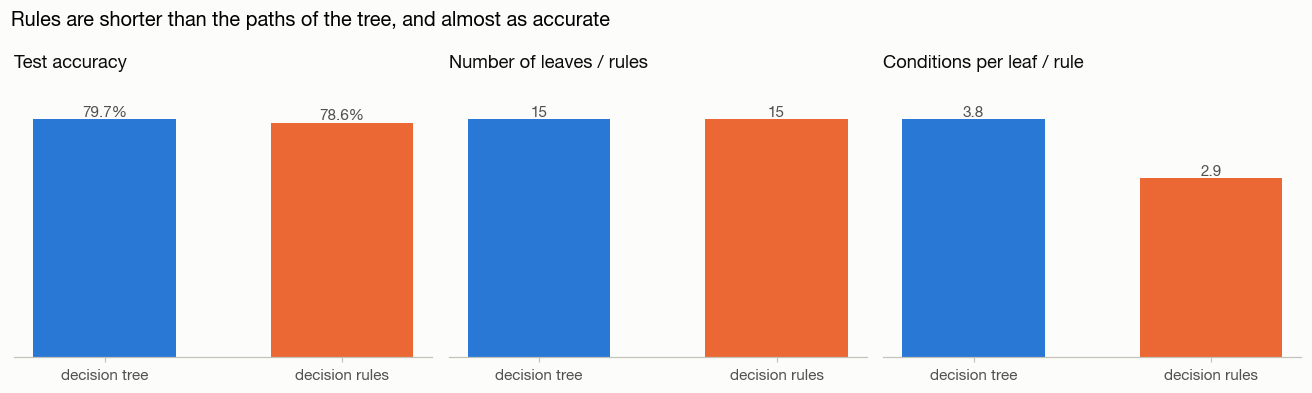

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [("Test accuracy", comparison.loc["test accuracy"], "{:.1%}"),
          ("Number of leaves / rules", comparison.loc["number of leaves / rules (with the default rule)"], "{:.0f}"),
          ("Conditions per leaf / rule", comparison.loc["conditions per leaf / rule"], "{:.1f}")]
for ax, (title, values, fmt) in zip(axes, panels):
    bars = ax.bar(["decision tree", "decision rules"], values.values, color=[BLUE, ORANGE], width=0.6)
    for bar, v in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", fontsize=10, color=INK2)
    ax.set_title(title)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.grid(False)
    ax.set_ylim(0, values.max() * 1.18)
fig.suptitle("Rules are shorter than the paths of the tree, and almost as accurate",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t4_07_tree_vs_rules")
plt.show()

- **Accuracy:** the rules are almost as good as the tree: 78.6% vs 79.7% on the test set (macro F1 0.80 vs 0.81).
- **Agreement:** both give the same answer for 97.8% of the test phones (only 4 of 182 differ). The default rule decided 2 test phones.
- **Simplicity:** there are as many rules as leaves (15, with the default rule), but the rules are shorter (2.9 conditions instead of 3.8), and each rule can be read on its own, without following the tree from the top.

So the **rule-based classifier** is easier to read and to explain, and it costs us about one percentage point of accuracy. The tree is a bit more accurate, and it shows how the questions depend on each other.

### 6.3 Classifying new phones
Finally, we describe four new phones and let both classifiers decide their segment. For the rules, we also show which rule decided.

In [25]:
def new_phone(chip, **specs):
    # We start from a typical phone (the median of the training set), set its chip family, and change the specs we give
    phone = X_train.median()
    phone[[f for f in features if f.startswith("chip_")]] = 0
    phone[f"chip_{chip}"] = 1
    for feature, value in specs.items():
        phone[feature] = value
    return phone

new_phones = pd.DataFrame({
    "Budget-style phone (Helio, 4 GB, 64 GB, no 5G)": new_phone("helio", processor_speed=2.0, ram_capacity=4, internal_memory=64,
        has_5g=0, has_nfc=0, refresh_rate=60, fast_charging=10, primary_camera_front=5),
    "Mid-range 5G phone (Dimensity, 8 GB, 128 GB)": new_phone("dimensity", processor_speed=2.4, ram_capacity=8, internal_memory=128,
        has_5g=1, has_nfc=0, refresh_rate=120, fast_charging=33, primary_camera_front=16),
    "Premium phone (Snapdragon, 8 GB, 256 GB, NFC)": new_phone("snapdragon", processor_speed=2.9, ram_capacity=8, internal_memory=256,
        has_5g=1, has_nfc=1, refresh_rate=120, fast_charging=67, primary_camera_front=32),
    "iPhone-style phone (Bionic, 6 GB, 128 GB)": new_phone("bionic", processor_speed=3.2, ram_capacity=6, internal_memory=128,
        has_5g=1, has_nfc=1, os_ios=1, refresh_rate=60, fast_charging=20, primary_camera_front=12, battery_capacity=3300,
        extended_memory_available=0, screen_size=6.1, ppi=460),
}).T[features]

tree_answer = tree.predict(new_phones)
tree_sure = tree.predict_proba(new_phones).max(axis=1)
rule_answer, rule_number = predict_with_rules(new_phones)
pd.DataFrame({"decision tree": [SEGMENTS[s] for s in tree_answer],
              "share of the leaf's phones in that segment": tree_sure,
              "decision rules": [SEGMENTS[s] for s in rule_answer],
              "rule that decided": [f"#{n + 1}: IF {rule_text(rules[n]['conditions'])}" if n >= 0 else "default rule"
                                    for n in rule_number]}, index=new_phones.index).style.format(
    {"share of the leaf's phones in that segment": "{:.0%}"}).format(escape="html", subset=["rule that decided"])

,decision tree,share of the leaf's phones in that segment,decision rules,rule that decided
"Budget-style phone (Helio, 4 GB, 64 GB, no 5G)",Budget,94%,Budget,#1: IF MediaTek Helio chip and front camera ≤ 14.5 MP
"Mid-range 5G phone (Dimensity, 8 GB, 128 GB)",Mid-range,81%,Mid-range,#6: IF 14.5 < front camera ≤ 22 MP and RAM > 5 GB and processor speed ≤ 2.65 GHz
"Premium phone (Snapdragon, 8 GB, 256 GB, NFC)",Premium,58%,Premium,#13: IF front camera > 14.5 MP and processor speed > 2.65 GHz and screen ≤ 6.79 inches
"iPhone-style phone (Bionic, 6 GB, 128 GB)",Flagship,100%,Flagship,#3: IF 11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz


Both classifiers put all four phones in the segment we would expect, and we can say **why**: the iPhone-style phone is a Flagship because of rule #3 (fast processor, more than 4 GB of RAM, 12 MP front camera), and the budget-style phone is a Budget phone because of rule #1 (Helio chip, front camera up to 14 MP). For the premium phone the tree is less sure: only 58% of the training phones in its leaf are Premium phones.

This is the big advantage of trees and rules over models like logistic regression: **every decision can be explained in plain words**.

# Summary of Task 4

| Task | What we did and found |
|---|---|
| 1. Dataset | 907 phones in 4 price segments (Budget 36%, Mid-range 36%, Premium 17%, Flagship 11%) |
| 2. Data preparation | 27 specs as features; no price and no rating (both contain the price); no scaling needed |
| 3. Splitting | stratified 80/20 split (725 / 182 phones) and 5 × repeated 5-fold cross-validation on the training set |
| 4a. Tree depth | the most accurate: depth 9 (76.1%, 101 leaves); our choice: depth 4 (73.4%, 16 leaves), after which one more level adds less than 1 point |
| 4b. Phones per leaf | for depth 4, the best is 3 phones per leaf (73.4%, 15 leaves) |
| Final tree | max_depth = 4, min_samples_leaf = 3: 15 leaves, 9 of 27 features used |
| 5. Test set | accuracy 79.7% (baseline 35.7%), macro F1 0.81, ROC-AUC 0.92; all mistakes but one between neighbouring segments; 74.7% on average over 20 random splits |
| 6. Decision rules | 14 rules + a default rule: 78.6% accuracy (tree: 79.7%), 2.9 conditions per rule (tree: 3.8) |

**Our answer:** yes, a small decision tree with at most 4 questions per phone can tell a phone's price segment from its specs alone for about 3 out of 4 phones, and when it is wrong, it is almost always only one segment off. The deciding specs are **RAM and processor speed**, the same specs that drove the price in Task 3. The rules put this into plain words: 4 GB of RAM without NFC means a Budget phone, a fast processor with a big screen means a Flagship.

**What we keep in mind**
- **A small tree is a choice:** a much bigger tree (101 leaves) would be about 3 points more accurate in cross-validation, but we couldn't show or explain it.
- **Trees are unstable:** with another random split, the tree and its rules would look somewhat different, and the test accuracy moves between about 69% and 82%.
- **The specs don't explain everything:** about 1 in 4 phones lands in the wrong segment, because the price also depends on things our data doesn't have, such as the brand's image, the design or the release date.